# Fuel up with OATmeals — The French Nominal Yield Curve

### Replication of Grishchenko, Moraux & Pakulyak (2020), *J. of Finance and Data Science* 6, 49–85 — and extension to today

This notebook estimates the **French nominal zero-coupon yield curve** every
trading day from the cross-section of fixed-coupon **OAT/BTAN** bid prices,
using the **Svensson (1994)** parametric curve fitted in the **Gürkaynak–Sack–
Wright (GSW)** style.

The paper's sample is **22 Oct 1987 → 10 Apr 2018**. Our Bloomberg extract runs
to **5 Jun 2026**, so beyond reproducing the paper we **extend the methodology
to today** and ask how the results change.

> **Before running:** execute `scripts/01_build_panel.py` and
> `scripts/02_fit_curves.py` once. They cache the filtered data and the daily
> fit (~5 min) as parquet files; every cell below just *loads* those caches, so
> the notebook runs in seconds.

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == 'notebooks') else pathlib.Path.cwd()))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from oatcurve import config, data_loading as dl, metrics, pipeline, svensson, analysis, plotstyle as ps

ps.apply_theme()   # shared thesis style: default font, light grid, Dark2 palette
EURO, PAPER_END = config.EURO_START, config.PAPER_END

params = pd.read_parquet(config.CACHE_DIR / "fit_params.parquet")
zero   = pd.read_parquet(config.CACHE_DIR / "zero_curve.parquet")
par    = pd.read_parquet(config.CACHE_DIR / "par_curve.parquet")
master = pd.read_parquet(config.CACHE_DIR / "master.parquet")
panel  = pd.read_parquet(config.CACHE_DIR / "panel.parquet")
span   = pd.read_parquet(config.CACHE_DIR / "maturity_span.parquet")  # traded-maturity range/day
bonds  = dl.build_bonds(master, panel, config.FILTERS)
LAST = params.index.max()
print(f"{len(params):,} daily curves fitted, {params.index.min().date()} -> {LAST.date()}")
print(f"{len(bonds)} bonds kept for fitting")

10,077 daily curves fitted, 1987-10-22 -> 2026-06-05
155 bonds kept for fitting


## 1. Data and universe (Section 3)

We use Bloomberg **bid** prices (per GSW). After the static filters of
Section 4.3, the universe is dominated by OATs with a handful of legacy BTANs.
Each line below is one security: it starts at its first available quote and
descends to zero remaining maturity at redemption. The dashed line marks the
launch of the euro (1 Jan 1999).

Kept for fit: 155 | OAT: 152 | BTAN: 3
Bonds quoted per day: min=6, median=63, max=155


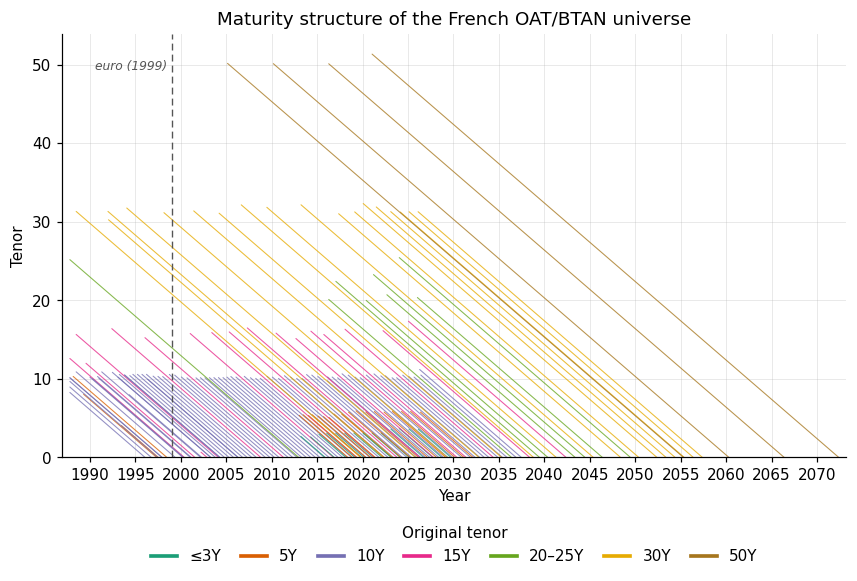

In [3]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

kept = master.query("kept_for_fit")
print("Kept for fit:", len(kept), "| OAT:", (kept.security_type=='OAT').sum(),
      "| BTAN:", (kept.security_type=='BTAN').sum())
daily_n = panel[list(bonds)].notna().sum(axis=1)
print(f"Bonds quoted per day: min={daily_n.min()}, median={int(daily_n.median())}, max={daily_n.max()}")

fig, ax = plt.subplots(figsize=(9.2,5.0))
for _, b in kept.iterrows():
    s = panel[b["isin"]].dropna()             # b["isin"] not b.isin (Series.isin is a method!)
    if s.empty: continue
    first, mat = s.index.min(), pd.Timestamp(b["maturity"])
    yrs = (mat-first).days/365.25
    if yrs <= 0: continue
    ax.plot([first, mat], [yrs, 0],           # colour by original tenor bucket
            color=ps.TENOR_COLORS[ps.tenor_bucket(b["orig_term"])],
            lw=.7, alpha=.78, solid_capstyle="round")
ax.set_ylim(bottom=0); ax.margins(x=.01)
ax.axvline(pd.Timestamp(EURO), color="#555555", ls=(0,(5,3)), lw=.9)
ax.annotate("euro (1999)", xy=(pd.Timestamp(EURO), ax.get_ylim()[1]*.94),
            xytext=(-50,0), textcoords="offset points", fontsize=8,
            color="#555555", style="italic", va="top")
ax.set(xlabel="Year", ylabel="Tenor",
       title="Maturity structure of the French OAT/BTAN universe")
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
handles = [Line2D([0],[0], color=ps.TENOR_COLORS[t], lw=2.4) for t in ps.TENOR_BUCKETS]
leg = ax.legend(handles, ps.TENOR_BUCKETS, title="Original tenor", ncol=7,
                loc="upper center", bbox_to_anchor=(.5,-.13),
                columnspacing=1.3, handlelength=1.7)
leg._legend_box.align = "center"
plt.show()

## 2. Methodology (Section 4)

**Svensson zero-coupon yield** (eq. 12), with `θ = (β0, β1, β2, β3, τ1, τ2)`:

$$y(m)=\beta_0+\beta_1\,G(m/\tau_1)+\beta_2\big[G(m/\tau_1)-e^{-m/\tau_1}\big]
       +\beta_3\big[G(m/\tau_2)-e^{-m/\tau_2}\big],\quad G(x)=\tfrac{1-e^{-x}}{x}.$$

Each day the six parameters minimise the **modified-duration-weighted squared
price errors** (eq. 14), pricing each bond's cash flows off the Svensson curve
(eq. 3) and comparing to the **dirty** bid price (clean + accrued):

$$\hat\theta_t=\arg\min_\theta\sum_k\Big[\tfrac{P^{obs}_k-P^{model}_k(\theta)}{D_k}\Big]^2 .$$

Constraints: $\tau_1,\tau_2,\beta_0>0$; $\beta_0+\beta_1$ free (negative short
rates allowed). The cell below draws the fitted forward, zero and par curves on
the latest date.

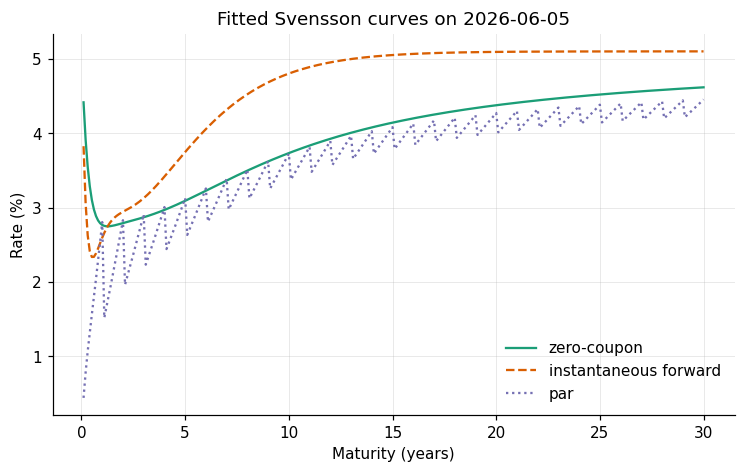

theta = {'beta0': np.float64(0.051), 'beta1': np.float64(0.0001), 'beta2': np.float64(-0.0557), 'beta3': np.float64(-0.051), 'tau1': np.float64(2.2671), 'tau2': np.float64(0.3716)}


In [4]:
theta = params.loc[LAST, pipeline.PARAM_COLS].to_numpy(float)
m = np.linspace(0.1, 30, 300)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(m, svensson.zero_yield(m, theta)*100, label="zero-coupon")
ax.plot(m, svensson.forward_rate(m, theta)*100, label="instantaneous forward", ls="--")
ax.plot(m, [svensson.par_yield(x, theta)*100 for x in m], label="par", ls=":")
ax.set(xlabel="Maturity (years)", ylabel="Rate (%)",
       title=f"Fitted Svensson curves on {LAST.date()}")
ax.legend(frameon=False); plt.show()
print("theta =", dict(zip(pipeline.PARAM_COLS, np.round(theta,4))))

## 3. Model fit (Section 5.1)

The overall fitting error (eq. 16) is the cross-sectional mean absolute
difference between observed and fitted yields, in basis points. In the euro
benchmark the model prices ~150 bonds with only six parameters to within a few
basis points.

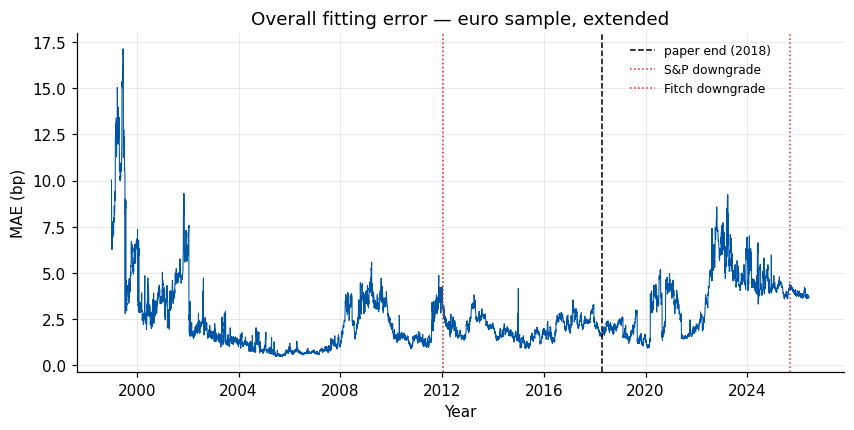

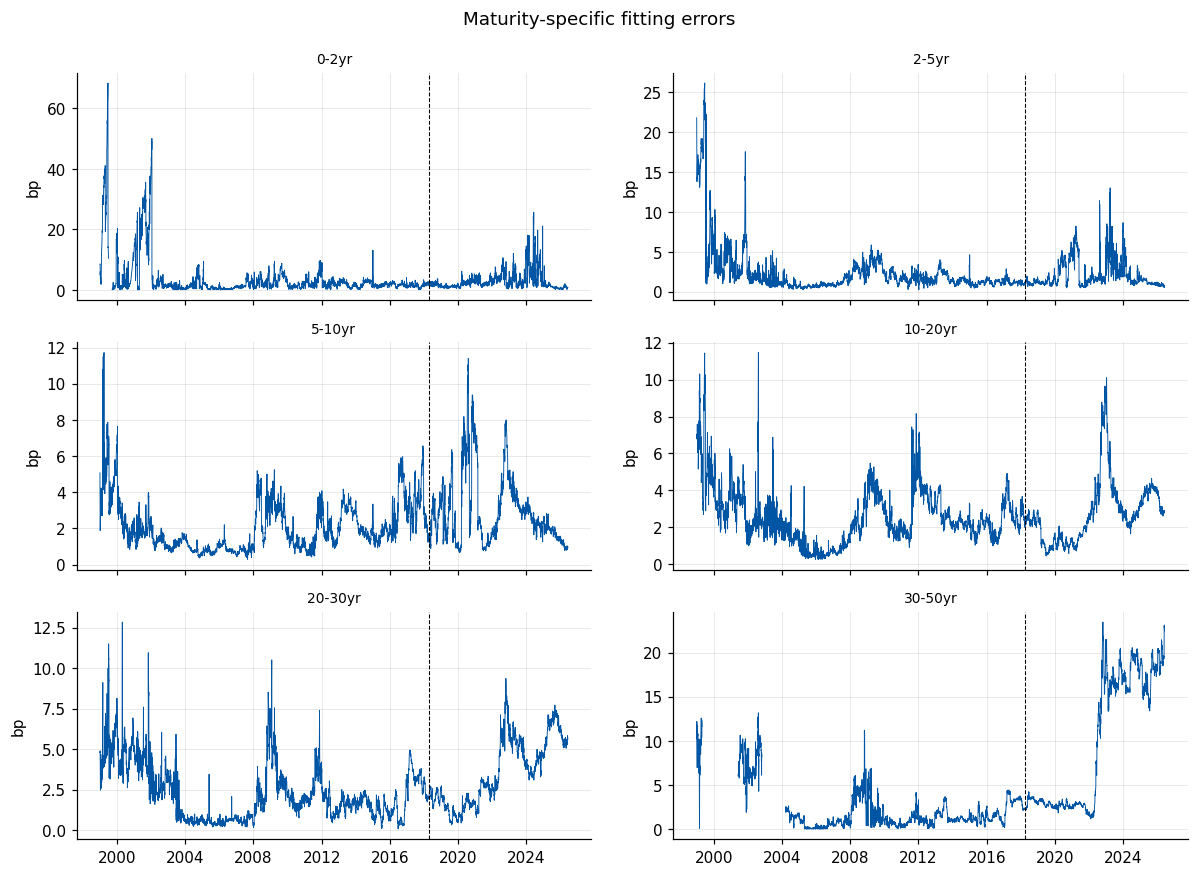

In [22]:
fig, ax = plt.subplots(figsize=(9,4))
euro = params.loc[EURO:]
ax.plot(euro.index, euro["mae"], lw=.7, color=ps.FRANCE_BLUE)
ax.axvline(pd.Timestamp(PAPER_END), color="k", ls="--", lw=1, label="paper end (2018)")
ax.axvline(pd.Timestamp(config.SP_DOWNGRADE), color="tab:red", ls=":", lw=1, label="S&P downgrade")
ax.axvline(pd.Timestamp("2025-09-12"), color="tab:red", ls=":", lw=1, label= "Fitch downgrade")
ax.set(xlabel="Year", ylabel="MAE (bp)", title="Overall fitting error — euro sample, extended")
ax.legend(frameon=False, fontsize=8, loc="upper right", bbox_to_anchor=(0.92, 1.0)); plt.show()

fig, axes = plt.subplots(3,2, figsize=(11,8), sharex=True)
for ax, lbl in zip(axes.ravel(), config.MATURITY_BIN_LABELS):
    ax.plot(euro.index, euro[f"mae_{lbl}"], lw=.6, color=ps.FRANCE_BLUE); ax.set_title(lbl, fontsize=9); ax.set_ylabel("bp")
    ax.axvline(pd.Timestamp(PAPER_END), color="k", ls="--", lw=.7)
fig.suptitle("Maturity-specific fitting errors", y=.99); plt.tight_layout(); plt.show()

**Table 1 — fitting-error statistics by period (bp).**

In [6]:
periods = analysis.standard_periods(LAST)
summary = analysis.fit_error_summary(params, periods)
summary[[("mae","mean"),("mae","std"),("mae","max"),("n_days","")]].round(2)

mae                 n_days
                             mean    std    max         
Full (1987-2018, paper)      7.00   9.12  53.48   7949.0
Euro (1999-2018, paper)      2.39   1.98  17.13   5028.0
Pre-euro (1987-1998)        14.93  10.96  53.48   2921.0
Post-paper (2018-today)      3.58   1.59   9.24   2129.0
Euro extended (1999-today)   2.75   1.95  17.13   7156.0
Full extended (1987-today)   6.28   8.25  53.48  10077.0

## 4. The fitted curve on selected dates (Section 5.1, Fig. 5)

Par-yield curve (line) with observed (circles) and predicted (crosses)
yields-to-maturity, on three dates from the paper plus the most recent date.

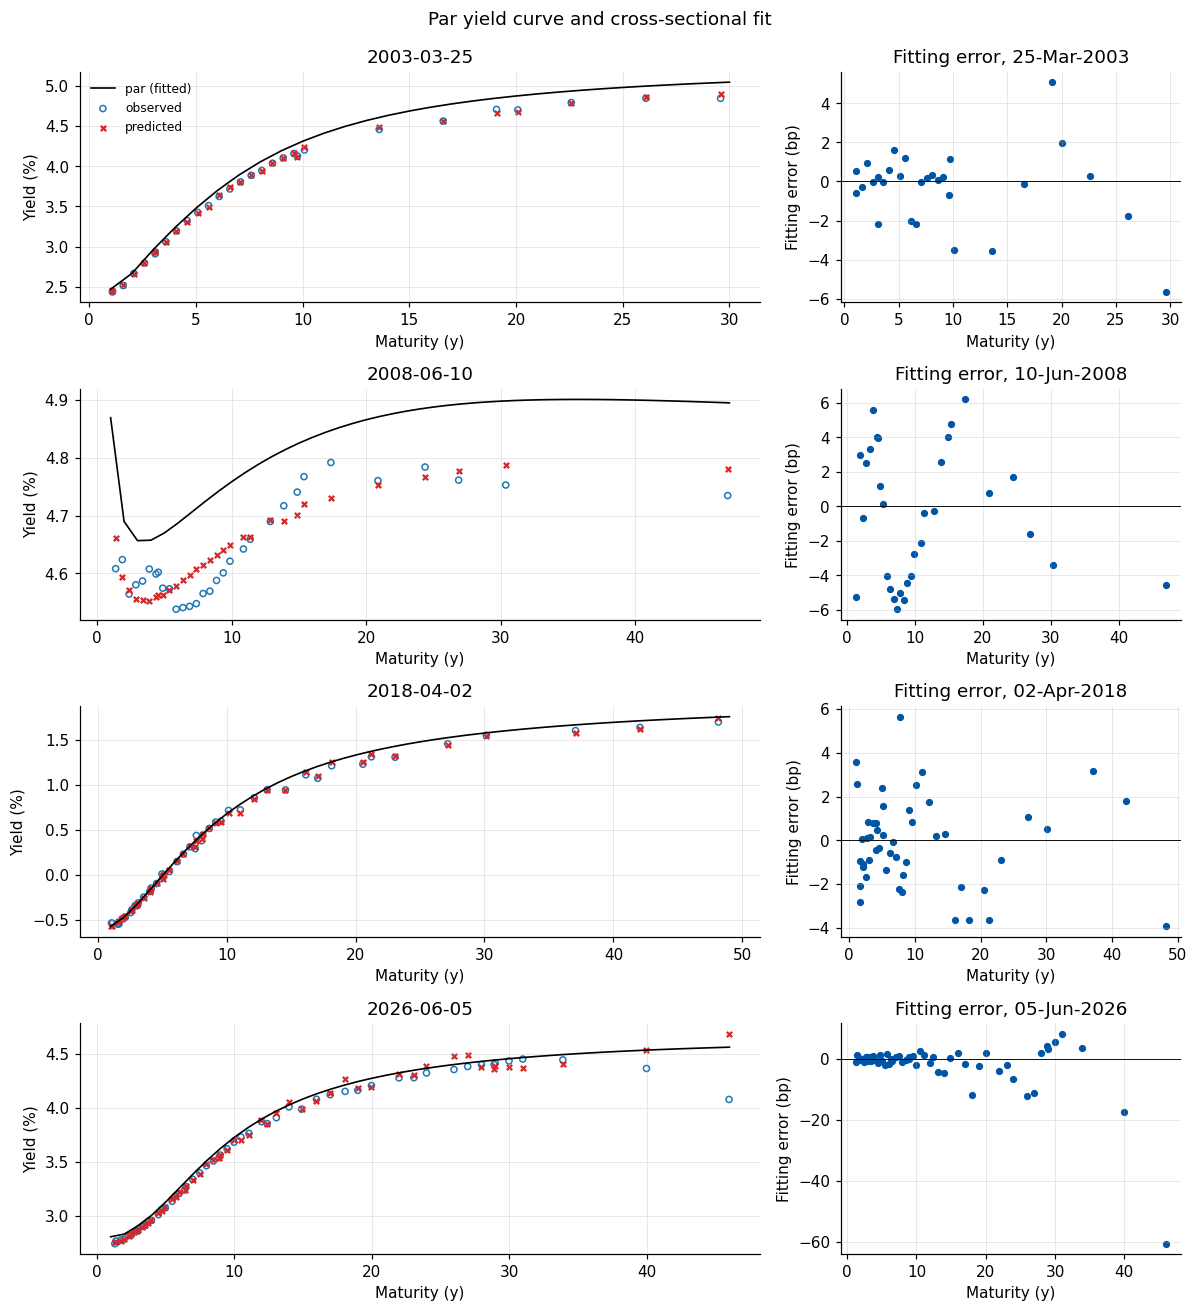

In [25]:
def nearest(idx, d): d = pd.Timestamp(d); return idx[np.argmin(np.abs(idx - d))]

dates = ["2003-03-25", "2008-06-10", "2018-04-02", LAST]
fig, axes = plt.subplots(len(dates), 2, figsize=(11, 3.0 * len(dates)),
                         gridspec_kw={"width_ratios": [2, 1]})
axes = np.atleast_2d(axes)
for i, dd_ in enumerate(dates):
    d = nearest(params.index, dd_)
    th = params.loc[d, pipeline.PARAM_COLS].to_numpy(float)
    tab, _ = metrics.cross_section_fit(d, bonds, panel, theta=th)
    g = np.arange(1, int(np.ceil(max(10, tab.maturity.max()))) + 1)  # integer grid: smooth par curve

    axL, axR = axes[i, 0], axes[i, 1]
    # left: par yield curve + observed / predicted YTM
    axL.plot(g, svensson.par_yield(g, th) * 100, "k", lw=1.1, label="par (fitted)")
    axL.scatter(tab.maturity, tab.y_obs, s=16, facecolors="none", edgecolors="tab:blue", label="observed")
    axL.scatter(tab.maturity, tab.y_fit, s=12, marker="x", color="tab:red", label="predicted")
    axL.set(title=str(pd.Timestamp(d).date()), xlabel="Maturity (y)", ylabel="Yield (%)")
    # right: security-specific fitting error = (observed - predicted) YTM, in bp
    axR.scatter(tab.maturity, (tab.y_obs - tab.y_fit) * 100, s=14, color=ps.FRANCE_BLUE)
    axR.axhline(0, color="k", lw=.6)
    axR.set(title=f"Fitting error, {pd.Timestamp(d):%d-%b-%Y}", xlabel="Maturity (y)", ylabel="Fitting error (bp)")

axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Par yield curve and cross-sectional fit", y=.99)
plt.tight_layout()
plt.show()

## 5. Dynamics of the zero curve (Section 5.2)

Fitted zero yields, the level/slope/curvature factors, and the principal-
component decomposition (Table 4). The level is the 10y yield, the slope is
10y−2y, and the curvature is 2·5y−2y−10y.

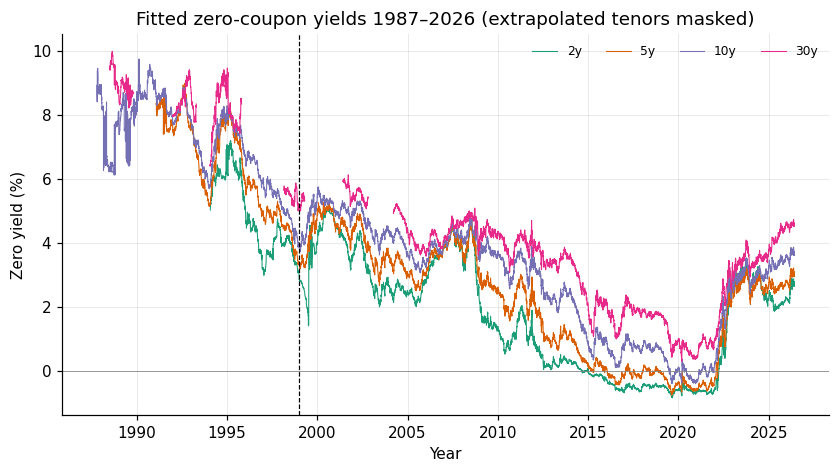

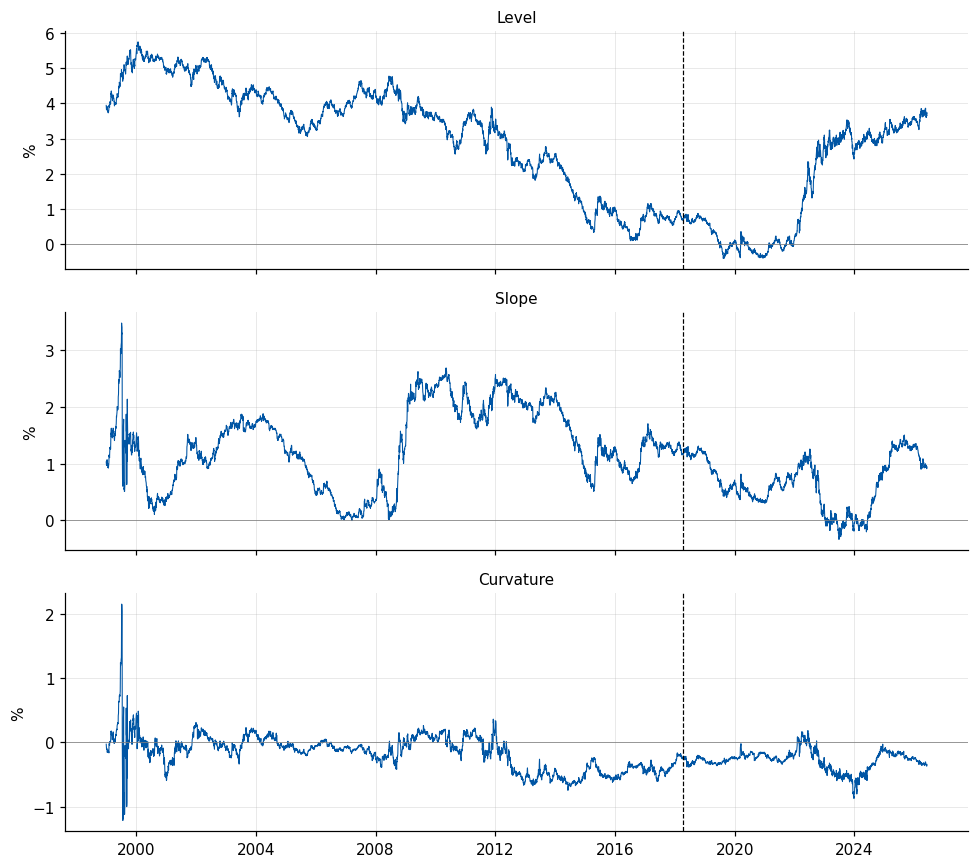

In [29]:
z = pipeline.mask_extrapolated(zero[["2y","5y","10y","30y"]], span)  # hide extrapolated tenors
fig, ax = plt.subplots(figsize=(9,4.5))
for t in ["2y","5y","10y","30y"]:
    ax.plot(z.index, z[t]*100, lw=.7, label=t)
ax.axvline(pd.Timestamp(EURO), color="k", ls="--", lw=.8); ax.axhline(0, color="grey", lw=.5)
ax.set(xlabel="Year", ylabel="Zero yield (%)", title="Fitted zero-coupon yields 1987–2026 (extrapolated tenors masked)")
ax.legend(ncol=4, frameon=False, fontsize=8); plt.show()

f = analysis.term_structure_factors(zero).loc[EURO:]
fig, axes = plt.subplots(3,1, figsize=(9,8), sharex=True)
for ax,c,t in zip(axes, ["level","slope","curvature"], ["Level","Slope","Curvature"]):
    ax.plot(f.index, f[c], lw=.7, color=ps.FRANCE_BLUE); ax.axhline(0, color="grey", lw=.5)
    ax.axvline(pd.Timestamp(PAPER_END), color="k", ls="--", lw=.8); ax.set_title(t, fontsize=10); ax.set_ylabel("%")
plt.tight_layout(); plt.show()

**Table 4 — share of variance explained by the first three principal components.**

In [9]:
rows = {}
for label, sl in [("Paper euro (1999-2018)", zero.loc[EURO:PAPER_END]),
                  ("Euro extended (1999-today)", zero.loc[EURO:]),
                  ("Full extended (1987-today)", zero)]:
    ratio,_ = analysis.pca_decomposition(sl); rows[label] = ratio
pd.DataFrame(rows).T.round(4)

,PC1,PC2,PC3
Paper euro (1999-2018),0.9646,0.0295,0.0055
Euro extended (1999-today),0.9672,0.0281,0.0044
Full extended (1987-today),0.8916,0.0976,0.0103


## 6. Market functioning — the HPW noise measure (Section 8.2, eq. 18)

The noise measure is the RMSE of the yield fitting errors; higher noise = less
arbitrage capital / poorer functioning. It collapses after the euro launch and
spikes during the GFC and the 2011–12 sovereign crisis.

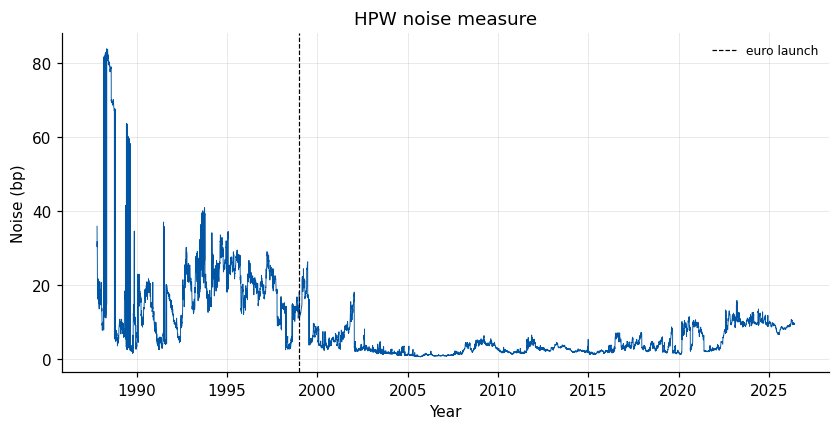

           mean    max
euro       4.44  26.25
pre-euro  19.80  83.84


In [30]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(params.index, params["noise"], lw=.6, color=ps.FRANCE_BLUE)
ax.axvline(pd.Timestamp(EURO), color="k", ls="--", lw=.8, label="euro launch")
ax.set(xlabel="Year", ylabel="Noise (bp)", title="HPW noise measure")
ax.legend(frameon=False, fontsize=8); plt.show()
print(params["noise"].groupby(np.where(params.index < pd.Timestamp(EURO),"pre-euro","euro")).agg(["mean","max"]).round(2))

## 7. On-the-run premium (Section 6, eq. 17)

Run `scripts/04_on_the_run.py` to populate `otr_premium.parquet`. The paper's
key result — *no* on-the-run premium on the French market — should appear as a
series fluctuating around zero, in sharp contrast to U.S. Treasuries.

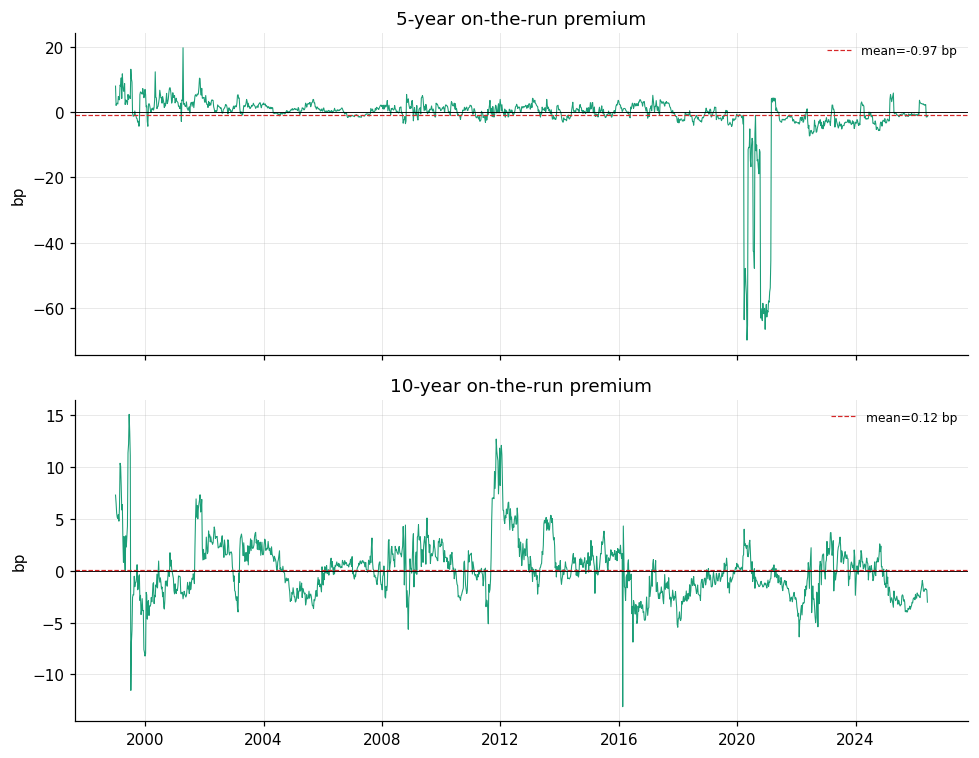

In [11]:
otr_path = config.CACHE_DIR / "otr_premium.parquet"
if otr_path.exists():
    prem = pd.read_parquet(otr_path)
    fig, axes = plt.subplots(2,1, figsize=(9,7), sharex=True)
    for ax,t in zip(axes,(5,10)):
        ax.plot(prem.index, prem[f"otr_{t}y"], lw=.7); ax.axhline(0, color="k", lw=.6)
        ax.axhline(prem[f"otr_{t}y"].mean(), color="tab:red", ls="--", lw=.8,
                   label=f"mean={prem[f'otr_{t}y'].mean():.2f} bp")
        ax.set(title=f"{t}-year on-the-run premium", ylabel="bp"); ax.legend(frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print("Run scripts/04_on_the_run.py first to compute the on-the-run premium.")

## 8. Extension — what changes when we run the methodology to today

The table compares the paper's euro benchmark (1999–2018) with the post-paper
window (2018–today) and the full extended euro sample. It is the headline of the
extension exercise: how fit quality, market noise and the level/slope of the
curve evolve once the most recent bonds and the post-2018 macro regime
(pandemic, the 2022–23 ECB tightening, the 2024 French political/fiscal stress)
are included.

In [12]:
f = analysis.term_structure_factors(zero)
windows = {"Paper euro (1999-2018)": (EURO, PAPER_END),
           "Post-paper (2018-today)": (PAPER_END, LAST),
           "Euro extended (1999-today)": (EURO, LAST)}
rows = {}
for label,(a,b) in windows.items():
    p, ff = params.loc[a:b], f.loc[a:b]
    rows[label] = {"n_days": len(p), "MAE mean (bp)": p.mae.mean(), "MAE max (bp)": p.mae.max(),
                   "noise mean (bp)": p.noise.mean(), "10y level mean (%)": ff.level.mean(),
                   "slope mean (%)": ff.slope.mean(), "bonds/day": p.n_bonds.mean()}
pd.DataFrame(rows).T.round(2)

,n_days,MAE mean (bp),MAE max (bp),noise mean (bp),10y level mean (%),slope mean (%),bonds/day
Paper euro (1999-2018),5028.0,2.39,17.13,3.39,3.28,1.33,33.36
Post-paper (2018-today),2129.0,3.58,9.24,6.92,1.60,0.67,48.07
Euro extended (1999-today),7156.0,2.75,17.13,4.44,2.78,1.14,37.73


### Takeaways

* The **euro-era fit remains excellent** out to 2026 (overall MAE of a few bp),
  confirming that the six-parameter Svensson form still spans the French curve
  even as the number of bonds and the maturity span grow.
* **Fit quality and noise** rise modestly in the post-2018 window relative to
  2008–2018, around episodes of stress (COVID-19, the 2022–23 rate shock, the
  2024 French budget/political tensions), echoing the GFC and 2011–12 pattern.
* The **level and slope** trace the full monetary cycle: deeply negative rates
  through 2021, the sharp 2022–23 repricing, and the 2024–26 normalisation —
  extending the paper's "declining rates since the GFC" narrative through a
  complete hiking-and-normalisation episode the original sample never saw.

*All figures and tables are also written to `output/` by the scripts.*